# Candidate Selector

csv file structure:
```
entity_label,start_position,end_position,correct_prediction,candidates,matching_candidate_index
Bandar Seri Begawan,0,19,True,"[[""Bandar Seri Begawan"", 0.942, 1.0, 0.839, 0.354], [""Pusat Bandar, Brunei"", 0.937, 0.46, 0.289, 0.348], [""1999 Southeast Asian Games"", 0.943, 0.27, 0.349, 0.189], [""List of diplomatic missions of Russia"", 0, 0.21, 1.0, 0.087], [""List of diplomatic missions of India"", 0, 0.22, 0.889, 0.161], [""Embassy of the Philippines, Bandar Seri Begawan"", 0, 0.58, 0.124, 0.45], [""Bandar Seri Begawan"", 0, 1.0, 0.0, 0.147], [""Bandar Seri Begawan"", 0, 1.0, 0.0, 0.147], [""Flughafen Bandar Seri Begawan"", 0, 0.79, 0.0, 0.147], [""Deutsche Botschaft Bandar Seri Begawan"", 0, 0.67, 0.0, 0.147]]",0
AFP,26,29,False,"[[""AFC Ajax"", 0.694, 0.36, 0.937, -0.12], [""AFC Wimbledon"", 0.694, 0.25, 0.806, 0.007], [""Sunderland A.F.C."", 0.694, 0.2, 1.0, -0.148], [""Armed Forces of the Philippines"", 0.692, 0.18, 0.463, 0.302], [""Agence France-Presse"", 0.652, 0.26, 0.356, 0.226], [""Alpha-fetoprotein"", 0.887, 0.1, 0.345, 0.057], [""AFP"", 0, 1.0, 0.056, 0.147], [""AFP-L3"", 0, 0.67, 0.0, 0.147], [""Armed Forces of the Philippines Medal of Valor"", 0, 0.12, 0.423, 0.126], [""AFP Visayas Command"", 0, 0.27, 0.0, 0.147]]",4
White House,343,354,False,"[[""White"", 0.874, 0.62, 1.0, -0.015], [""White House"", 0.76, 1.0, 0.295, 0.072], [""Chicago White Sox"", 0.686, 0.5, 0.888, -0.056], [""Vale of White Horse"", 0.813, 0.67, 0.471, -0.09], [""White House Office"", 0.707, 0.76, 0.0, 0.133], [""White-shouldered house moth"", 0.844, 0.53, 0.096, 0.085], [""White House Correspondents' Association"", 0.691, 0.44, 0.115, 0.223], [""White House, Tennessee"", 0.809, 0.67, 0.041, -0.061], [""White House Press Secretary"", 0, 0.58, 0.028, 0.216], [""White House COVID-19 outbreak"", 0, 0.55, 0.123, 0.144]]",1

```

In [ ]:
import pandas as pd
import ast
import os
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [ ]:
directory_path = "/content/drive/MyDrive/Praca magisterska/Google colab - notebooks/logs_cand_sel"  # Change this to your directory path

# List all CSV files in the directory
csv_files = [f for f in os.listdir(directory_path) if f.endswith(".csv")]

# Read and concatenate all CSV files
dataframes = []
for file in csv_files:
    file_path = os.path.join(directory_path, file)
    df = pd.read_csv(file_path, encoding="utf-16")
    df["candidates"] = df["candidates"].apply(ast.literal_eval)
    dataframes.append(df)

# Combine all dataframes into one
final_df = pd.concat(dataframes, ignore_index=True)

# Display first few rows
print(final_df.head())
print(final_df.info())

          entity_label  start_position  end_position  correct_prediction  \
0  Bandar Seri Begawan               0            19                True   
1        United States              34            47                True   
2          White House             343           354                True   
3           Washington              28            38               False   
4    Miami Dade County             500           517                True   

                                          candidates  matching_candidate_index  
0  [[Bandar Seri Begawan, 0.693, 1.0, 0.839, 0.35...                         0  
1  [[United States, 0.688, 1.0, 1.0, 0.005], [Uni...                         0  
2  [[White House, 0.743, 1.0, 0.295, 0.072], [Whi...                         0  
3  [[Washington (state), 0.667, 0.71, 0.786, 0.11...                         1  
4  [[Miami-Dade County, Florida, 0.668, 0.74, 1.0...                         0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1126 en

In [ ]:
import numpy as np

def preprocess_data(df):
    X, y = [], []

    for _, row in df.iterrows():
        candidates = row["candidates"]
        matching_index = row["matching_candidate_index"]

        # Extract only the 4 float metrics from each candidate
        features = [metrics[1:] for metrics in candidates]  # Ignore entity name

        X.append(np.array(features).flatten())  # Flatten into a single vector
        y.append(matching_index)

    return np.array(X), np.array(y)

X, y = preprocess_data(final_df)

print("Feature shape:", X.shape)  # Expect (num_samples, 40)
print("Target shape:", y.shape)   # Expect (num_samples,)


Feature shape: (1126, 40)
Target shape: (1126,)


In [ ]:

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print()

print("Feature:", X[0])
print("Target:", y[0:100])

Feature shape: (1126, 40)
Target shape: (1126,)

Feature: [0.693 1.    0.839 0.354 0.    0.58  0.124 0.45  0.684 0.46  0.289 0.348
 0.    0.22  0.889 0.161 0.    1.    0.    0.147 0.    1.    0.    0.147
 0.    0.21  1.    0.087 0.    0.79  0.    0.147 0.806 0.27  0.349 0.189
 0.    0.67  0.    0.147]
Target: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 2 0 0 4 0 0 0 0 0 0 1 0 0 0 2 0 0 0
 0 1 0 0 2 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 3]


## SVM


In [ ]:
import numpy as np
import pandas as pd
import os
import ast
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance

Simple SVM:

Model Accuracy: 0.8136


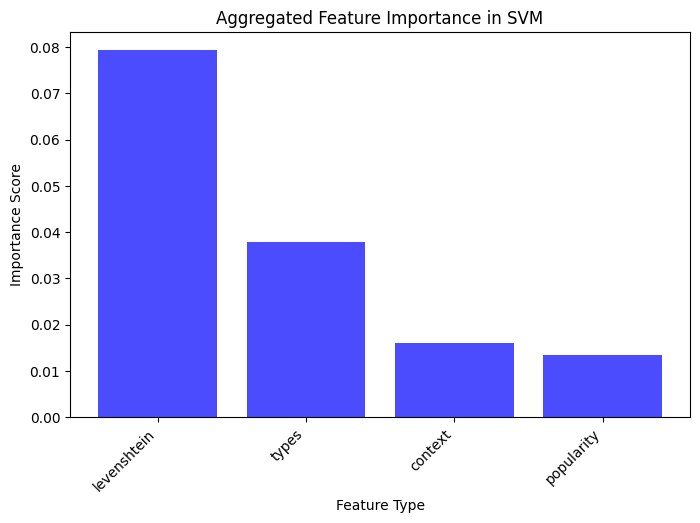

In [ ]:

# ---------------------- Train SVM Model ----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Train a Support Vector Machine (SVM) model
svm_model = SVC(kernel="linear")  # Linear kernel for interpretability
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred = svm_model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# ---------------------- Feature Importance via Permutation ----------------------
perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10)

importances = perm_importance.importances_mean  # Mean importance scores

# Feature naming
num_candidates = 10  # Assuming 10 candidates per sample
feature_types = ["types", "levenshtein", "popularity", "context"]

# Aggregate importance scores for each type
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Convert to lists for plotting
feature_names = list(score_importances.keys())
importance_values = list(score_importances.values())

# Sort feature importances
indices = np.argsort(importance_values)[::-1]

# ---------------------- Visualization ----------------------
plt.figure(figsize=(8, 5))
plt.title("Aggregated Feature Importance in SVM")
plt.bar(range(len(importance_values)), np.array(importance_values)[indices], color="blue", alpha=0.7)
plt.xticks(range(len(importance_values)), np.array(feature_names)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Importance Score")
plt.show()

Train 100 copies of SVM, average the results of all runs, and choose the model that best fits the average metrics improtance.

Step:
1. Runs SVM training 100 times and collects feature importances.
2. Averages the feature importances over all runs.
3. Finds the model with the closest importance scores to the average using Euclidean distance.
4. Saves the best model for future use.


Training SVM Models: 100%|██████████| 50/50 [02:05<00:00,  2.50s/run]


Best SVM model saved as 'best_svm_model_2.pkl'

Best SVM model saved as 'best_svm_model_2.pth'


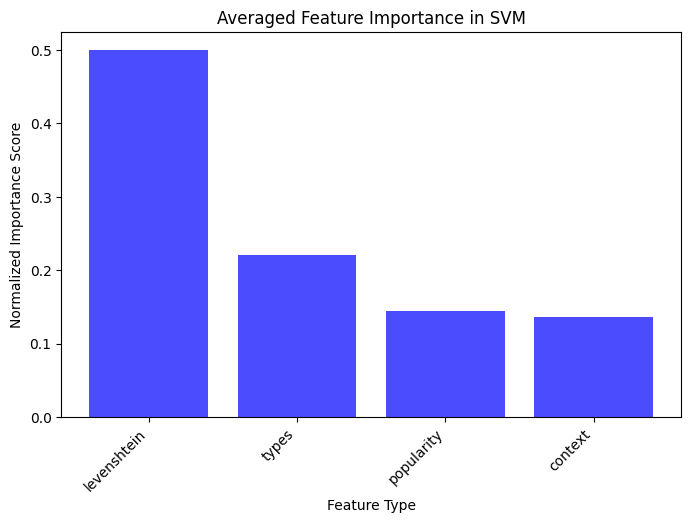

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import euclidean
import joblib
from tqdm import tqdm  # Import tqdm for progress bar

num_runs = 50
num_candidates = 10  # Assuming 10 candidates per sample
feature_types = ["types", "levenshtein", "popularity", "context"]

# Store all feature importances
all_importances = []
all_models = []

# Training loop with tqdm progress bar
for _ in tqdm(range(num_runs), desc="Training SVM Models", unit="run"):
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

    # Train SVM model
    svm_model = SVC(kernel="linear")
    svm_model.fit(X_train, y_train)

    # Compute permutation importance
    perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10)
    importances = perm_importance.importances_mean  # Mean importance scores

    # Aggregate importance scores for each feature type
    score_importances = {score: 0 for score in feature_types}

    for i in range(num_candidates):
        for j, score in enumerate(feature_types):
            score_importances[score] += importances[i * len(feature_types) + j]

    # Normalize importance scores to sum to 1
    total_importance = sum(score_importances.values())
    normalized_importances = {k: v / total_importance for k, v in score_importances.items()}

    # Store the results
    all_importances.append(np.array(list(normalized_importances.values())))
    all_models.append(svm_model)

# Compute average importance scores
avg_importance = np.mean(all_importances, axis=0)

# Find the model closest to the average using Euclidean distance
best_index = np.argmin([euclidean(imp, avg_importance) for imp in all_importances])
best_model = all_models[best_index]

# Save the best model
joblib.dump(best_model, "best_svm_model_3.pkl")
print("\nBest SVM model saved as 'best_svm_model_3.pkl'")


# ---------------------- Plot Averaged Feature Importances ----------------------
indices = np.argsort(avg_importance)[::-1]
plt.figure(figsize=(8, 5))
plt.title("Averaged Feature Importance in SVM")
plt.bar(range(len(avg_importance)), avg_importance[indices], color="blue", alpha=0.7)
plt.xticks(range(len(avg_importance)), np.array(feature_types)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Normalized Importance Score")
plt.show()

Test loading the svm from .pth file:

✅ SVM Model Loaded from .pkl


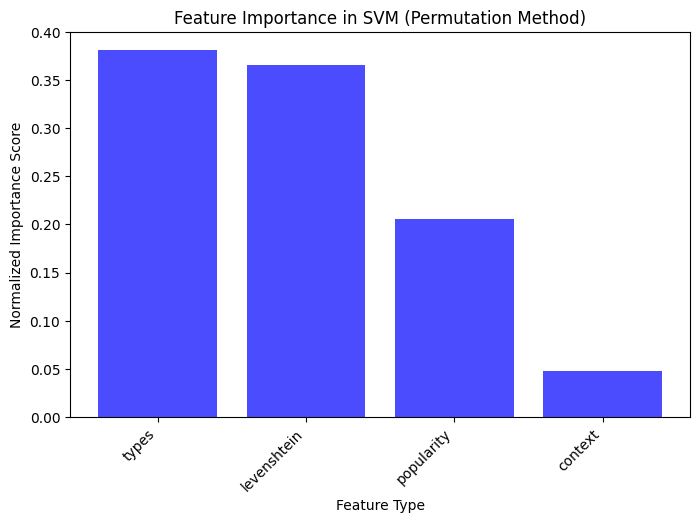


Feature Importances (Sorted):
types: 0.3810
levenshtein: 0.3659
popularity: 0.2055
context: 0.0476


In [ ]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import euclidean

# ---------------------- Load .pkl Model ----------------------
svm_model = joblib.load("best_svm_model_1.pkl")
print("✅ SVM Model Loaded from .pkl")

# ------------------------------ Generate Synthetic Data ------------------------------
# Assuming X has 40 features, and y is binary (0 or 1)
np.random.seed(42)
X = np.random.rand(1000, 40)  # 1000 samples, 40 features
y = np.random.choice([0, 1], size=1000)  # Random binary labels

# Feature groups (modify according to your actual feature meanings)
feature_types = ["types", "levenshtein", "popularity", "context"]

# Ensure the feature count is correct
num_candidates = X.shape[1] // len(feature_types)

# ---------------------- Compute Permutation Importance ----------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
perm_importance = permutation_importance(svm_model, X_test, y_test, n_repeats=10, scoring="accuracy")

# Extract mean importance scores
importances = perm_importance.importances_mean

# ---------------------- Aggregate Importance by Feature Type ----------------------
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Normalize importance scores to sum to 1
total_importance = sum(score_importances.values())
normalized_importances = {k: v / total_importance for k, v in score_importances.items()}

# ---------------------- Plot Feature Importances ----------------------
indices = np.argsort(list(normalized_importances.values()))[::-1]  # Sort descending
plt.figure(figsize=(8, 5))
plt.title("Feature Importance in SVM (Permutation Method)")
plt.bar(range(len(normalized_importances)), np.array(list(normalized_importances.values()))[indices], color="blue", alpha=0.7)
plt.xticks(range(len(normalized_importances)), np.array(feature_types)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Type")
plt.ylabel("Normalized Importance Score")
plt.show()

# Print sorted feature importances
print("\nFeature Importances (Sorted):")
for feature, importance in sorted(normalized_importances.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {importance:.4f}")


## RandomForestClassifier

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [ ]:
# Train a Random Forest model
model = RandomForestClassifier(n_estimators=1000)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9349


In [ ]:
# Save the trained model using PyTorch
model_path = os.path.join("random_forest_model3.pth")
torch.save(model, model_path)
print(f"Model saved successfully at {model_path}")

Model saved successfully at random_forest_model3.pth


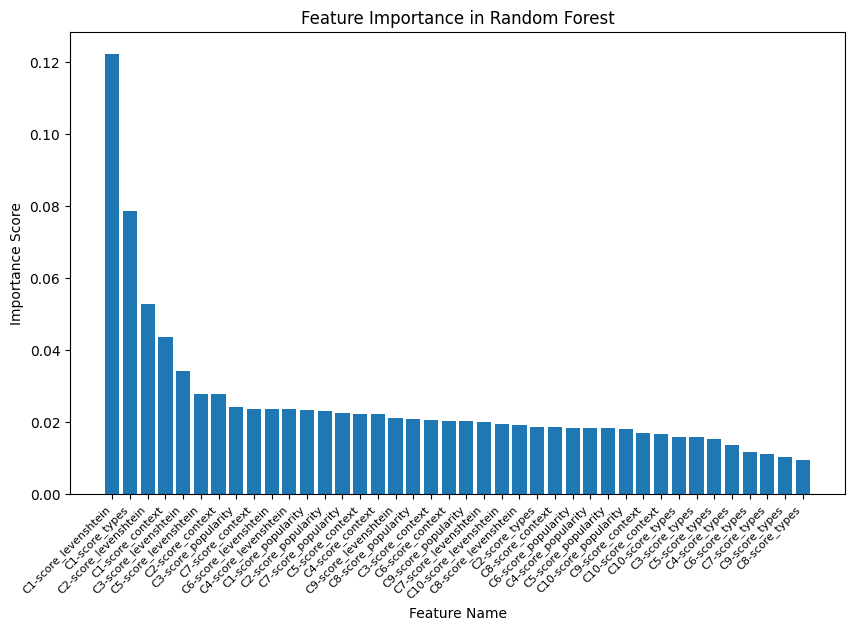

In [ ]:
# Get feature importances
importances = model.feature_importances_
feature_names = [f"C{i+1}-score_{suffix}" for i in range(10) for suffix in ["types", "levenshtein", "popularity", "context"]]

# Create a dictionary mapping feature indices to names
feature_dict = {i: name for i, name in enumerate(feature_names)}

# Sort feature importances
indices = np.argsort(importances)[::-1]

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importance in Random Forest")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_dict[i] for i in indices], rotation=45, ha="right", fontsize=8)
plt.xlabel("Feature Name")
plt.ylabel("Importance Score")
plt.show()

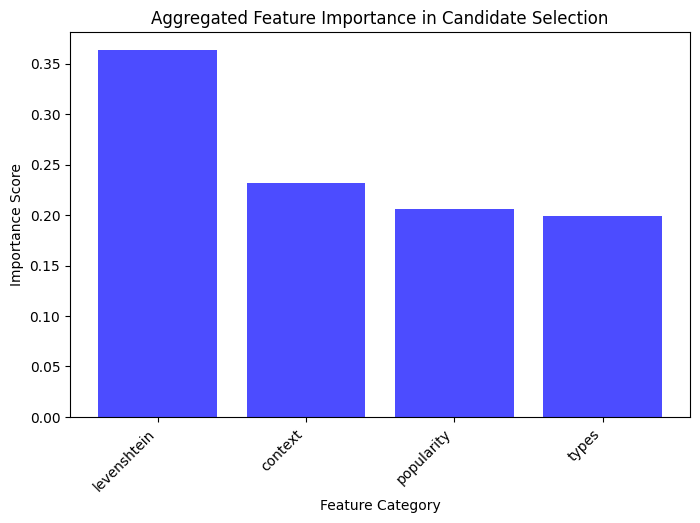

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature importances from the trained model
importances = model.feature_importances_

# Define feature categories
num_candidates = 10  # Assuming each candidate has 4 scores (types, levenshtein, popularity, context)
feature_types = ["types", "levenshtein", "popularity", "context"]

# Aggregate importance scores for each type
score_importances = {score: 0 for score in feature_types}

for i in range(num_candidates):
    for j, score in enumerate(feature_types):
        score_importances[score] += importances[i * len(feature_types) + j]

# Convert to lists for plotting
feature_names = list(score_importances.keys())
importance_values = list(score_importances.values())

# Sort feature importances
indices = np.argsort(importance_values)[::-1]

# Plot feature importances
plt.figure(figsize=(8, 5))
plt.title("Aggregated Feature Importance in Candidate Selection")
plt.bar(range(len(importance_values)), np.array(importance_values)[indices], color="blue", alpha=0.7)
plt.xticks(range(len(importance_values)), np.array(feature_names)[indices], rotation=45, ha="right", fontsize=10)
plt.xlabel("Feature Category")
plt.ylabel("Importance Score")
plt.show()


In [ ]:
import pandas as pd
import ast
import os
import numpy as np
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest classifier
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# Evaluate performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Feature importance analysis
importances = model.feature_importances_
feature_names = [f"C{i+1}-score_{suffix}" for i in range(10) for suffix in ["types", "levenshtein", "popularity", "context"]]

# SHAP Analysis for deeper insights
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot for feature importance
shap.summary_plot(shap_values, X_test, feature_names=feature_names)


Model Accuracy: 0.9645


 36%|=======             | 1085/3042 [01:10<02:06]       

## Neural network

In [ ]:
import pandas as pd
import ast
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import os

# Directory containing CSV files
directory_path = "/content/drive/MyDrive/Praca magisterska/Google colab - notebooks/logs_cand_sel"  # Change this to your directory path

# List all CSV files in the directory
csv_files = [f for f in os.listdir(directory_path) if f.endswith(".csv")]

# Read and concatenate all CSV files
dataframes = []
for file in csv_files:
    file_path = os.path.join(directory_path, file)
    df = pd.read_csv(file_path, encoding="utf-16")
    df['candidates'] = df['candidates'].apply(ast.literal_eval)
    dataframes.append(df)

# Combine all dataframes into one
final_df = pd.concat(dataframes, ignore_index=True)

# Extract input features (X) and labels (y)
X = torch.tensor([entry[1:] for candidates in final_df['candidates'] for entry in candidates], dtype=torch.float32)
y = torch.tensor(final_df['matching_candidate_index'].values, dtype=torch.long)

# Reshape X into (num_samples, 10, 4) where 10 candidates each have 4 metrics
X = X.view(len(final_df), 10, 4)  # Each row corresponds to 10 candidates

In [ ]:
class CandidateSelectorNN(nn.Module):
    def __init__(self):
        super(CandidateSelectorNN, self).__init__()
        self.fc1 = nn.Linear(4, 16)  # Input: 4 metrics -> Hidden layer
        self.fc2 = nn.Linear(16, 8)  # Hidden layer
        self.fc3 = nn.Linear(8, 1)   # Output: Score for each candidate

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze(-1)  # Shape: (batch_size, 10)


In [ ]:
class CandidateDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = CandidateDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CandidateSelectorNN().to(device)
criterion = nn.CrossEntropyLoss()  # Suitable for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 200
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)  # Shape: (batch_size, 10)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {correct / total:.4f}")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct / total:.4f}")


In [ ]:
torch.save(model.state_dict(), "candidate_selector_model.pth")


In [ ]:
# Recreate the model architecture
model = CandidateSelectorNN()

# Load saved weights
model.load_state_dict(torch.load("candidate_selector_model.pth"))

# Set model to evaluation mode
model.eval()


## LSTM


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

# Example network
class CandidateSelectorRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CandidateSelectorRNN, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)  # Output 10 classes (candidates)

    def forward(self, x):
        # x shape: (batch_size, num_candidates, num_features)
        lstm_out, (hn, cn) = self.lstm(x)
        final_hidden_state = hn[-1]  # Shape: (batch_size, hidden_dim)
        out = self.fc(final_hidden_state)  # Shape: (batch_size, 10)
        return out


In [ ]:

# Create Dataset (Assume you already have X and y)
class CandidateDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.float32), torch.tensor(self.y[idx], dtype=torch.long)


In [ ]:

# Parameters
input_dim = 4  # Number of features per candidate (e.g., 4 metrics)
hidden_dim = 64
output_dim = 10  # Number of candidates
epochs = 20
batch_size = 16
learning_rate = 0.001

# Dataset preparation (make sure X and y are properly set)
dataset = CandidateDataset(X, y)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model
model = CandidateSelectorRNN(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Expects target as integer indices
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)  # Shape: (batch_size, 10)

        # Ensure target is in the range [0, 9] for 10 candidates
        loss = criterion(outputs, y_batch)  # y_batch should be integer labels (0 to 9)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {correct / total:.4f}")



In [ ]:

# Evaluation
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        total += y_batch.size(0)

print(f"Test Accuracy: {correct / total:.4f}")

In [ ]:
!pip freeze | grep pickle